In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from IPython.display import display, Markdown


In [2]:
odf_com = pd.read_csv('raw/comments.csv')
odf_sub = pd.read_csv('raw/submissions.csv')

In [6]:
odf_com.head()
sdf = odf_sub.copy()
sdf["created_utc"] = pd.to_datetime(sdf["created_utc"], unit="s")

cdf = odf_com.copy()
cdf["created_utc"] = pd.to_datetime(cdf["created_utc"], unit="s")


In [7]:

display(Markdown(f"""
## Dataset Overview

| | Submissions | Comments |
|---|---|---|
| **Count** | {len(sdf):,} | {len(cdf):,} |
| **Date range** | {sdf.created_utc.min().date()} → {sdf.created_utc.max().date()} | {cdf.created_utc.min().date()} → {cdf.created_utc.max().date()} |
| **Unique authors** | {sdf.author.nunique():,} | {cdf.author.nunique():,} |
| **Avg score** | {sdf.score.mean():.1f} | {cdf.score.mean():.1f} |
"""))


## Dataset Overview

| | Submissions | Comments |
|---|---|---|
| **Count** | 1,000 | 881 |
| **Date range** | 2008-01-29 → 2009-01-06 | 2008-02-24 → 2008-09-15 |
| **Unique authors** | 128 | 217 |
| **Avg score** | 13.7 | 1.8 |


In [8]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

# submissions — text col is already title + selftext
sub_texts = sdf["text"].fillna("").tolist()
sub_embeddings = model.encode(sub_texts, show_progress_bar=True, batch_size=64)
np.save("sub_embeddings.npy", sub_embeddings)

# comments
com_texts = cdf["body"].fillna("").tolist()
com_embeddings = model.encode(com_texts, show_progress_bar=True, batch_size=64)
np.save("com_embeddings.npy", com_embeddings)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/14 [00:00<?, ?it/s]

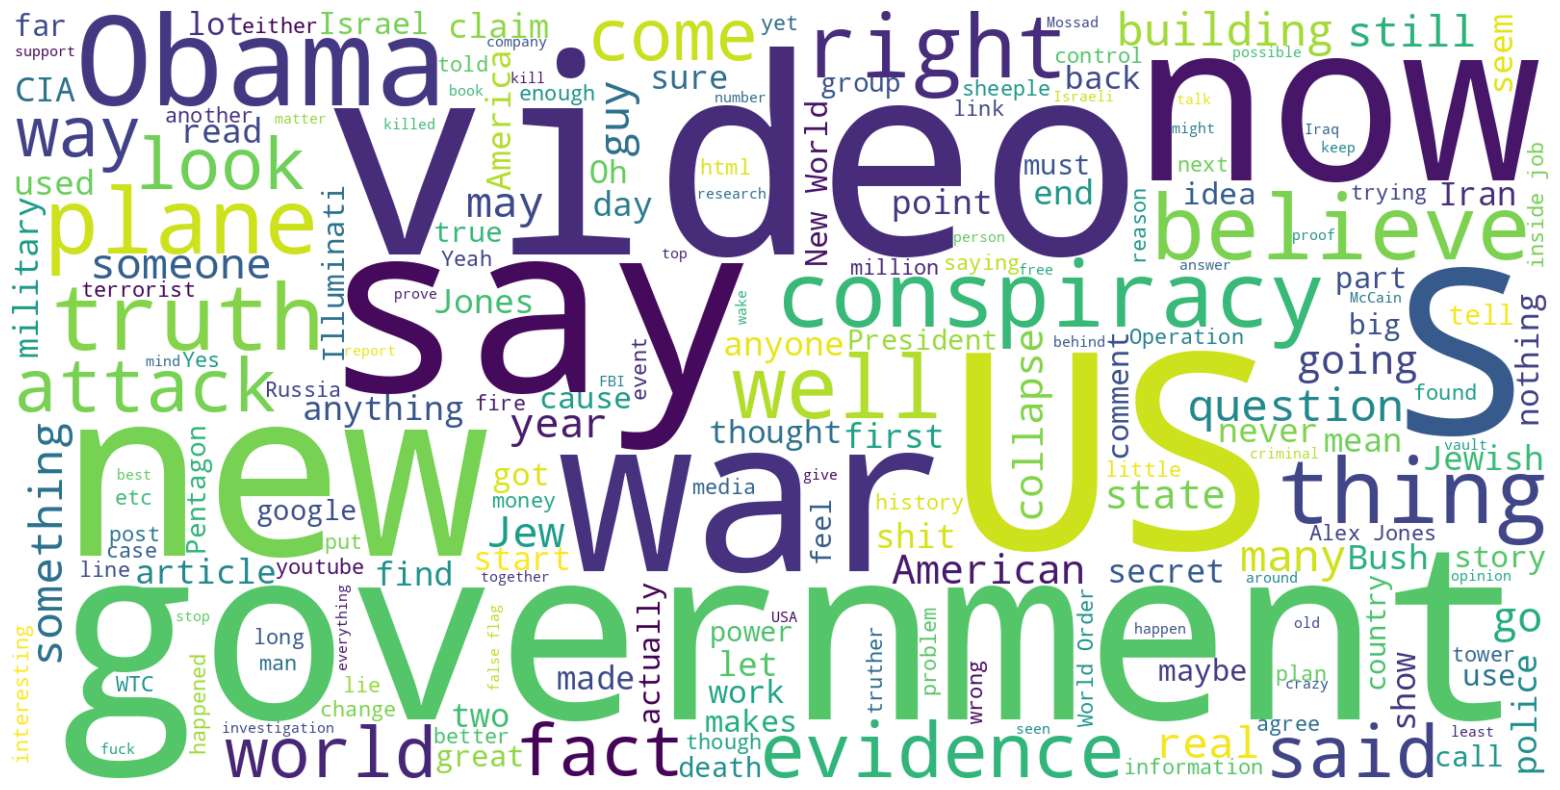

In [12]:
# pip install wordcloud scikit-learn matplotlib

from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import matplotlib.pyplot as plt
import numpy as np

from wordcloud import STOPWORDS

custom = {"https", "http", "www", "com", "reddit", "deleted", "removed", "will", "u", "amp", "gt", "just", "like", "one", "get", "would", "people", "think", "know", "time", "really", "even", "see", "also", "make", "much", "good", "bad", "take", "want", "need"}
stopwords = STOPWORDS | custom

all_text = " ".join(sdf["text"].fillna("").tolist() + cdf["body"].fillna("").tolist())
wc = WordCloud(width=1600, height=800, background_color="white",
               stopwords=stopwords, max_words=200).generate(all_text)
plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")

plt.tight_layout()
plt.savefig("wordcloud.png", dpi=150)
plt.show()



In [13]:

# ── LDA ───────────────────────────────────────────────────────────────────────
N_TOPICS = 10

vec = CountVectorizer(max_features=5000, stop_words="english",
                      min_df=5, ngram_range=(1, 2))
dtm = vec.fit_transform(sdf["text"].fillna("").tolist())

lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=42,
                                n_jobs=-1, max_iter=20)
lda.fit(dtm)


terms = vec.get_feature_names_out()
for i, comp in enumerate(lda.components_):
    top = [terms[j] for j in comp.argsort()[-15:][::-1]]
    print(f"Topic {i+1}: {', '.join(top)}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Topic 1: obama, real, public, truth, bin, want, laden, bin laden, conspiracies, dead, say, post, september, people, know
Topic 2: law, bush, martial, people, martial law, security, money, bailout, operation, history, homeland, bank, video, know, homeland security
Topic 3: alex, alex jones, jones, government, world, iran, states, free, united, usa, russia, israel, united states, financial, death
Topic 4: amp, america, american, crisis, financial, cia, 2008, conspiracy, north, world, economy, street, war, trying, north american
Topic 5: conspiracy, video, new, reddit, change, best, theory, com, plan, obama, know, cut, wake, think, americans
Topic 6: new, world, order, new world, world order, wtc, anthrax, liberty, inside, claims, 11 inside, interesting, obama, government, revealed
Topic 7: war, false, attack, pentagon, flag, military, terror, false flag, 911, children, mossad, iraq, flight, information, report
Topic 8: global, secret, illuminati, news, obama, nwo, david, just, al, great,

In [19]:
import pyLDAvis
import pyLDAvis.lda_model   # newer import name
vis = pyLDAvis.lda_model.prepare(lda, dtm, vec)
pyLDAvis.save_html(vis, "lda_vis.html")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/Users/sodikroehler/Documents/WORKBENCH/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=11714) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Users/sodikroehler/Documents/WORKBENCH/.venv/lib/python3.13/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=11714) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warnin